<a href="https://colab.research.google.com/github/Marcin19721205/WSBNeuronowe/blob/main/Keras_Tuner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wprowadzenie

Ten notebook jest prostym przykładem wykorzystania biblioteki Keras Tuner do automatycznego poszukiwania parametrów sieci i jej architektury.


Biblioteka Keras Tuner pozwala określić jakie hiperparametry i w jakim zakresie mają być przeszukiwane. Co do zasady potrzebujemy trzech składników:

1. Funkcji budującej sieć neuronową - funkcja przyjmuje obiekt hp - czyli zestaw aktualnie przetwarzanych hiperparametrów.
2. Ścieżki, do której zapisywane będą wyniki poszukiwania.
3. Zestawu danych do szkolenia.

# Import bibliotek

In [ ]:
%pip install keras_tuner

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 KB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kerastuner as kt
krs = tf.keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import fetch_california_housing

<ipython-input-2-738955477d68>:5: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


#  Wczytanie zbioru danych

W ramach ćwiczenia wykorzystamy zbiór California Housing, posiadający 8 zmiennych wyrażonych w róznych jednostkach.

Wartośc docelowa, którą przewidujemy - mediana ceny mieszkania.

In [ ]:
california = fetch_california_housing()


In [ ]:
print(california.DESCR)


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [ ]:
X, y = california.data, california.target
X = pd.DataFrame(X, columns=california.feature_names)

In [ ]:
# nie potrzebujemy danych geografcznych
X = X.drop(columns=['Latitude', 'Longitude'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Przygotowanie modelu dla Keras Tunera

W Keras Tunerze musimy wskazać, w jaki sposób mają być wybierane parametry. Dla poszczególnych typów parametrów mamy następujące możliwości:

1. Wartości całkowitoliczbowe (int) - **hp.Int(NAME, min_value=..., max_value=..., step=...)**
    1. name - każdy parametr musi mieć swoją unikalną nazwę, po której potem znajdziemy jego optymalną wartość
    2. min_value - najmniejsza dopuszczalna wartość parametru
    3. max_value - maksymalna wartość przedziału
    4. step - inkrementacja w kolejnych iteracjach
2. Wybór z listy dostępnych wartości - hp.Choice(NAME, values=[...])
    1. name - jak wyżej
    2. values - lista dopuszczalnych wartości spośród których można wybierać


Przygotowujemy funkcję, która zamiast definiować **gotowy** model z parametrami, w jego miejsce używa paramterów Keras Tunera.

Argumentem takiej funkcji jest **hp**, czyli obiekt wybierający hiperparametry.

In [ ]:
def build_model(hp):
    model = krs.models.Sequential()

    # Ile ma być neuronów w warstwie ukrytej. Parametr: od 4 do 16, idąc co 2
    hp_units = hp.Int('units', min_value=4, max_value=16, step=2)

    # Jakie chcemy mieć aktywacje?
    hp_activations = hp.Choice('activation', values=['tanh', 'relu'])

    # Automatyczna normalizacja zmiennych
    model.add(krs.layers.BatchNormalization())
    # Warstwa ukryta - zamiast jednostek i aktywacji - podajemy parametry
    model.add(krs.layers.Dense(hp_units, hp_activations))
    model.add(krs.layers.BatchNormalization())
    model.add(krs.layers.Dense(1, 'relu'))
    model.compile(optimizer='adam', loss='mse', metrics=['mse', 'mape'])
    return model

Przygotowanie **tunera**, czyli obiektu, który będzie wybierać architekturę sieci

In [ ]:
tuner = kt.Hyperband(
    build_model,                    # Funkcja budująca moel
    objective='mse',               # Funkcja celu
    max_epochs=10,                  # Max. liczba epok
    hyperband_iterations=2,         # ilość iteracji wyboru parametrów
    directory="tuner_results",      # katalog do zapisu wyników
    project_name='tuner_tutorial')  # nazwa eksperymentu

Odpalenie poszukiwania parametrów.

In [ ]:
tuner.search(X_train, y_train, epochs=10, validation_split=0.2)

Trial 20 Complete [00h 00m 06s]
mse: 0.7204742431640625

Best mse So Far: 0.5099126100540161
Total elapsed time: 00h 01m 53s


Po zakończeniu - pobranie nahlepszych parametrów

In [ ]:
best_activation = tuner.get_best_hyperparameters()[0].get('activation')
best_no_units = tuner.get_best_hyperparameters()[0].get('units')
print(f"Best activation: {best_activation}, best no. units: {best_no_units}")

Best activation: tanh, best no. units: 14


Zbudowanie najlepszego modelu i wyszkolenie go

In [ ]:
best_params = tuner.get_best_hyperparameters()[0]
model = tuner.hypermodel.build(best_params)
history = model.fit(X_train, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
413/413 [==============================] - 2s 3ms/step - loss: 1.9046 - mse: 1.9046 - mape: 59.5534 - val_loss: 0.7769 - val_mse: 0.7769 - val_mape: 34.0251
Epoch 2/20
413/413 [==============================] - 1s 3ms/step - loss: 0.6056 - mse: 0.6056 - mape: 35.8818 - val_loss: 0.6177 - val_mse: 0.6177 - val_mape: 30.2401
Epoch 3/20
413/413 [==============================] - 2s 4ms/step - loss: 0.5575 - mse: 0.5575 - mape: 34.3353 - val_loss: 0.5586 - val_mse: 0.5586 - val_mape: 28.6821
Epoch 4/20
413/413 [==============================] - 2s 6ms/step - loss: 0.5294 - mse: 0.5294 - mape: 33.2599 - val_loss: 0.5862 - val_mse: 0.5862 - val_mape: 30.1249
Epoch 5/20
413/413 [==============================] - 2s 4ms/step - loss: 0.5208 - mse: 0.5208 - mape: 32.5436 - val_loss: 0.5564 - val_mse: 0.5564 - val_mape: 29.9546
Epoch 6/20
413/413 [==============================] - 3s 7ms/step - loss: 0.5138 - mse: 0.5138 - mape: 32.2979 - val_loss: 0.5719 - val_mse: 0.5719 - val_mape: 

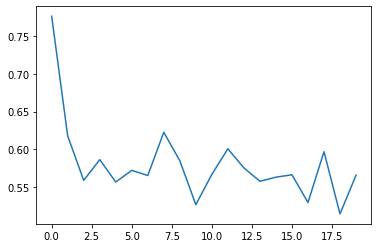

In [ ]:
plt.plot(history.history['val_mse'])

Ewaluacja na zbiorze testowym

In [ ]:
model.evaluate(X_test, y_test)

129/129 [==============================] - 0s 2ms/step - loss: 0.5570 - mse: 0.5570 - mape: 27.9674


[0.5570166707038879, 0.5570166707038879, 27.967422485351562]